In [ ]:
# LabOne Q:
from laboneq.simple import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import pandas as pd
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import *
print(laboneq.__version__)

2.51.0


In [ ]:
from tools import *

In [ ]:
device_setup, session = initialization(emulation = False)

In [105]:
# qubit ground state [6.77788288 6.80982122 6.84365284 6.8696416  6.90045666 6.93228756 6.9650209  7.00248583 7.0300547]
res_lo_freq = 7e9
qb_lo_freq = 5.2e9
qubit_label = "Q3"  # change if needed
# qb_freq = 5.23809e9 #Q1
# qb_freq = 5.147960e9 #Q2
qb_freq = 5.176650e9 #Q3


# res_freq = 6.77788288e9 #Q1
# res_freq = 6.80982122e9 #Q2
res_freq = 6.84365284e9 #Q3

rlx_time = 50e-6

delay_start = 1e-8
delay_stop = 100e-6
delay_num = 301

measure_pulse_length = 5e-6

# drive_pulse_amp = 0.305 #Q1 305
# drive_pulse_amp = 0.449 #Q2
drive_pulse_amp = 0.721 #Q3
# drive_pulse_amp = 0.184 #Q4
# drive_pulse_amp = 0.263 #Q5
# drive_pulse_amp = 0.188 #Q6

# drive_pulse_length = 1.373e-6 # Q1 0.646e-6
# drive_pulse_length = 2.716e-6 # Q2
drive_pulse_length = 0.411e-6 # Q3
# drive_pulse_length = 0.974e-6 # Q4
# drive_pulse_length =  0.979e-6# Q5
# drive_pulse_length = 1.034e-6 # Q6

drive_range = -10 #was 0
num_averages = 12  # average number = 2^n, n_max = 17
measure_range = -30  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.2
acquire_range = -45

In [107]:
## define pulses
# qubit drive pulse - use amplitude calibrated by amplitude Rabi experiment
x180 = pulse_library.const(uid="x180", length=drive_pulse_length, amplitude=drive_pulse_amp)
# readout drive pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=measure_pulse_length, amplitude=measure_amp)


In [108]:
delay_sweep = LinearSweepParameter(uid="delay", start=delay_start, stop=delay_stop, count=delay_num)

# Create Experiment
exp = Experiment(
    uid="T1 experiment",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],)
    ## experimental pulse sequence
    # outer loop - real-time, cyclic averaging in standard integration mode
with exp.acquire_loop_rt(
    uid="shots",
    count=pow(2, num_averages),
    acquisition_type=AcquisitionType.SPECTROSCOPY,
):
    # inner loop - sweep over delay between qubit excitation and readout pulse
    # right alignment makes sure the readout section follows a fixed timing, being the last element in each shot
    with exp.sweep(
        uid="sweep", parameter=delay_sweep
    ):
        # qubit drive pulse followed by variable delay
        with exp.section(uid="qubit_excitation"):
            exp.play(signal="drive", pulse=x180)
            exp.delay(signal="drive", time=delay_sweep)
        # qubit readout pulse and data acquisition
        with exp.section(uid="qubit_readout", play_after="qubit_excitation"):
            # play readout pulse
            # exp.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            # exp.acquire(
            #     signal="acquire",
            #     handle="ac_0",
            #     kernel=readout_weighting_function,
            # )
            exp.measure(
                    measure_signal='measure',
                    measure_pulse=readout_pulse,
                    acquire_signal="acquire",
                    integration_length = measure_pulse_length,
                    handle="t1_exp",
                    reset_delay = 50e-6,
                )
        # relax time after readout - for signal processing and qubit relaxation to ground state
        with exp.section(uid="relax", length=rlx_time):
            exp.reserve(signal="measure")
            exp.reserve(signal = "acquire")

In [109]:
# map exp to qubit 0
exp.set_signal_map(signal_map_default())


In [110]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq -qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
exp.set_calibration(exp_calibration)

In [111]:
# compile the experiment on the open instrument session
compiled_t1 = session.compile(exp)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/T1", compiled_t1)

[2025.09.20 23:33:41.084] INFO    Starting LabOne Q Compiler run...
[2025.09.20 23:33:41.197] INFO    Schedule completed. [0.106 s]
[2025.09.20 23:33:41.445] INFO    Code generation completed for all AWGs. [0.247 s]
[2025.09.20 23:33:41.447] INFO    Completed compilation step 1 of 1. [0.357 s]
[2025.09.20 23:33:41.453] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.09.20 23:33:41.453] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.09.20 23:33:41.453] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.09.20 23:33:41.460] INFO      device_shfqc        0       1209            0           1     20000  
[2025.09.20 23:33:41.460] INFO      device_shfqc_sg     1        611            2           1      1664  
[2025.09.20 23:33:41.460] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.09.20 23:33:41.460] INFO      TOTAL                       1820 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\T1_2025-09-20-23-33-41.html

In [112]:
# plot_simulation(session.compiled_experiment, start_time=1e-6, length=1000e-6)
# # run on qubit 0

In [113]:
T1_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")

# --- Make output folder + timestamp ---
outdir = "T1_results"
os.makedirs(outdir, exist_ok=True)

[2025.09.20 23:33:42.135] INFO    Starting near-time execution...
[2025.09.20 23:33:42.245] INFO    Estimated RT execution time: 191.62 s.
[2025.09.20 23:36:53.953] INFO    Finished near-time execution.


Saved figure to T1_results\T1_experiment_Q3_20250920T233654.png
Saved data to T1_results\T1_experiment_Q3_20250920T233654.csv


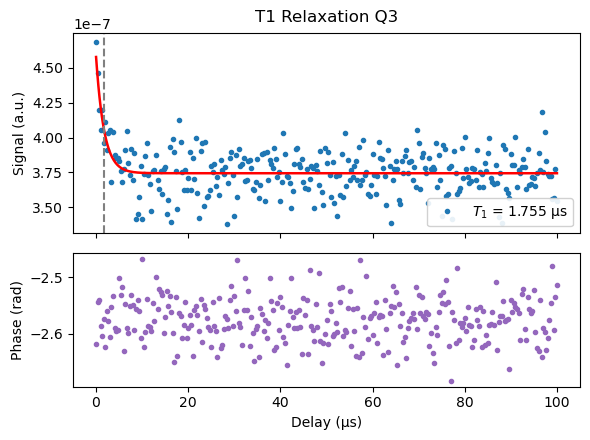

In [114]:
# ---------- Settings ----------
T1_data = T1_results.get_data("t1_exp")            # complex data
T1_data_axis = T1_results.get_axis("t1_exp")[0]    # seconds

# Convert to μs for plotting
x = 1e6 * np.asarray(T1_data_axis, float)          # μs
y = np.abs(T1_data).astype(float)                  # linear magnitude (a.u.)
phase_rad = np.angle(T1_data)

# Clean + sort
m = np.isfinite(x) & np.isfinite(y)
x, y, phase_rad = x[m], y[m], phase_rad[m]
idx = np.argsort(x)
x, y, phase_rad = x[idx], y[idx], phase_rad[idx]

# ---------- Fit model (in linear units) ----------
def T1_model(t_us, A, T1_us, C):
    return A * np.exp(-t_us / T1_us) + C

p0 = [y.max(), max(np.median(x), 1e-6), y.min()]
bounds = ([0.0, 0.0, -np.inf], [np.inf, np.inf, np.inf])

popt, _ = curve_fit(T1_model, x, y, p0=p0, bounds=bounds, maxfev=20000)
A_fit, T1_fit_us, C_fit = popt

# Smooth curve for display
xf = np.linspace(x.min(), x.max(), 800)
y_fit = T1_model(xf, *popt)

# ---------- Plot ----------
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                        gridspec_kw={'height_ratios': [1.5, 1.0]})

# Top: magnitude in a.u. with fit overlay
axs[0].plot(x, y, 'o', ms=3, label="data")
axs[0].plot(xf, y_fit, '-r', lw=1.8, label="fit")
axs[0].axvline(T1_fit_us, color="grey", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Signal (a.u.)")
axs[0].legend([rf"$T_1$ = {T1_fit_us:.3f} μs"], loc="lower right", framealpha=0.9)
axs[0].set_title(f"T1 Relaxation {qubit_label}", fontsize=12, pad=8)

# Bottom: phase vs time (optional)
axs[1].plot(x, phase_rad, 'o', ms=3, color="tab:purple")
axs[1].set_xlabel("Delay (μs)")
axs[1].set_ylabel("Phase (rad)")

plt.tight_layout()

# ---------- Save figure ----------
fig_path = os.path.join(outdir, f"T1_experiment_{qubit_label}_{timestamp}.png")
plt.savefig(fig_path, dpi=600)
print(f"Saved figure to {fig_path}")

# ---------- Save CSV ----------
df = pd.DataFrame({
    "Delay_us": x,
    "Magnitude_linear": y,
    "Fit_linear_at_x": T1_model(x, *popt),
    "Phase_rad": phase_rad,
    "A_fit": np.full_like(x, A_fit, dtype=float),
    "T1_fit_us": np.full_like(x, T1_fit_us, dtype=float),
    "C_fit": np.full_like(x, C_fit, dtype=float),
})
csv_path = os.path.join(outdir, f"T1_experiment_{qubit_label}_{timestamp}.csv")
df.to_csv(csv_path, index=False)
print(f"Saved data to {csv_path}")

plt.show()